# Bank Marketing: Who Subscribes to a Term Deposit?
**Group assignment: Jupyter Notebook & Libraries for Data Science (Rome Business School)**

A Portuguese bank phoned customers to offer a term deposit. We want to (1) understand who subscribes and (2) check whether Machine Learning can help pick promising customers for future campaigns.

Data: UCI Bank Marketing, `bank-full.csv` (45,211 rows, target `y` = subscribed yes/no).

**Assignment checklist**
1. Explore the data (EDA)
2. Prepare the data (numerical + categorical, include/exclude variables)
3. Baseline: train/test split + Logistic Regression + precision/recall/F1
4. Compare at least two more scikit-learn models
5. Feature engineering (at least two new features, with reasoning)
6. Interpret results + business use in a future campaign

In [1]:
import os, io, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                              roc_curve)

SEED = 42                      # fixed seed for reproducibility
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## Load the data
We read `bank-full.csv` from the notebook folder if it is there, otherwise we download it from the UCI repository (works also in Google Colab).

In [2]:
if os.path.exists("bank-full.csv"):
    df = pd.read_csv("bank-full.csv", sep=";")
else:
    url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
    outer = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read()))
    inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
    df = pd.read_csv(inner.open("bank-full.csv"), sep=";")

print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# 1. Explore the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
# Missing values, duplicates and basic statistics
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe().round(1)

Missing values: 0
Duplicate rows: 0


,age,balance,day,duration,campaign,pdays,previous
count,45211.0,45211.0,45211.0,45211.0,45211.0,45211.0,45211.0
mean,40.9,1362.3,15.8,258.2,2.8,40.2,0.6
std,10.6,3044.8,8.3,257.5,3.1,100.1,2.3
min,18.0,-8019.0,1.0,0.0,1.0,-1.0,0.0
25%,33.0,72.0,8.0,103.0,1.0,-1.0,0.0
50%,39.0,448.0,16.0,180.0,2.0,-1.0,0.0
75%,48.0,1428.0,21.0,319.0,3.0,-1.0,0.0
max,95.0,102127.0,31.0,4918.0,63.0,871.0,275.0


There are no empty cells, but some categories are literally called `unknown` (e.g. `poutcome`, `contact`). We treat `unknown` as its own category. In `pdays`, the value -1 means the customer was never contacted before.

no     39922
yes     5289
Name: y, dtype: int64
no     88.3
yes    11.7
Name: y, dtype: float64


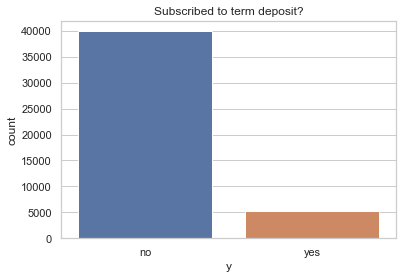

In [5]:
# Target balance
counts = df["y"].value_counts()
print(counts)
print((df["y"].value_counts(normalize=True) * 100).round(1))
sns.countplot(data=df, x="y")
plt.title("Subscribed to term deposit?")
plt.show()

The classes are **imbalanced**: only a small minority says yes. So plain accuracy is misleading (always answering "no" already scores high). We will focus on precision, recall, F1 and ROC AUC.

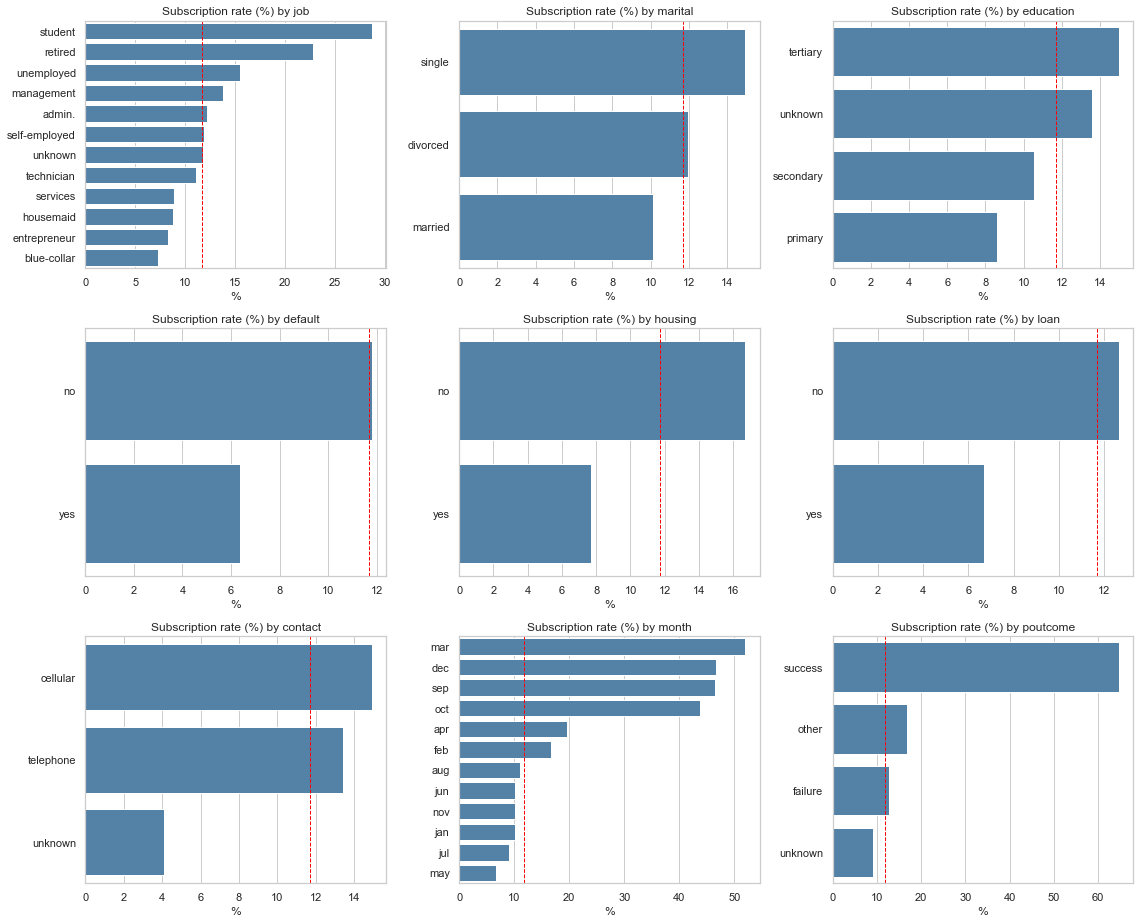

In [6]:
# Subscription rate by each categorical variable
df["target"] = (df["y"] == "yes").astype(int)
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = df.groupby(col)["target"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color="steelblue")
    ax.axvline(df["target"].mean() * 100, color="red", ls="--", lw=1)
    ax.set_title(f"Subscription rate (%) by {col}")
    ax.set_xlabel("%"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

The red dashed line is the overall rate. Categories to the right of it convert better than average.

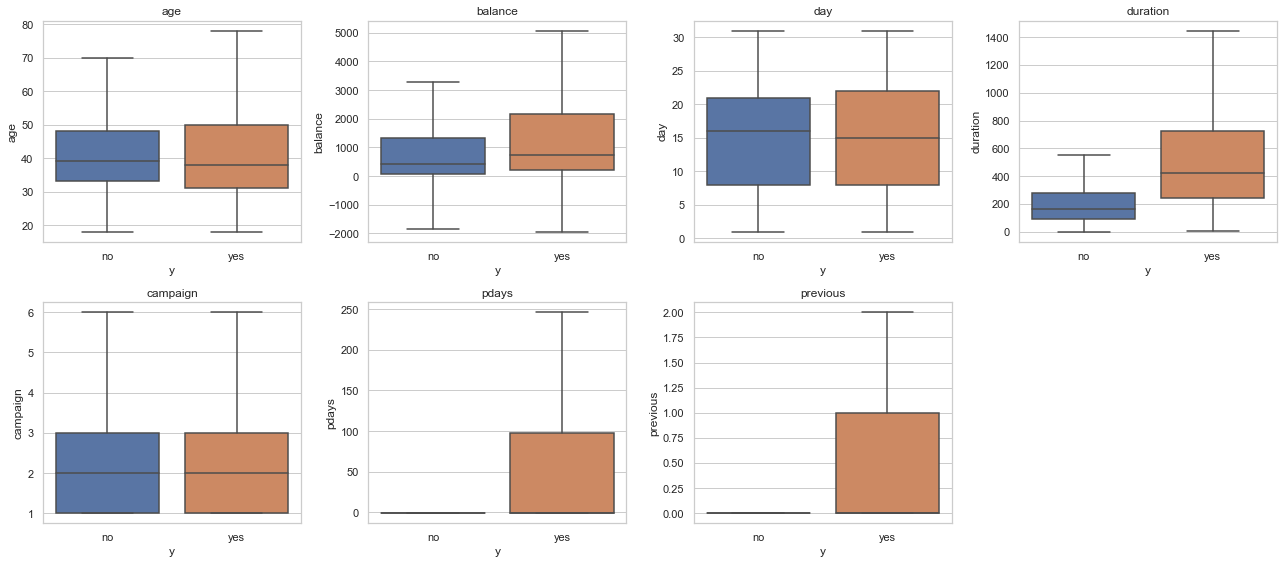

In [7]:
# Numerical variables: distribution for yes vs no
num_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x="y", y=col, ax=ax, showfliers=False)
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

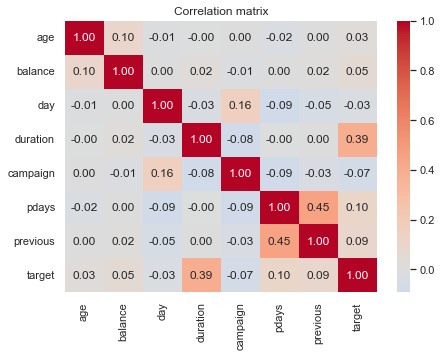

In [8]:
# Correlation of numeric variables with the target
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols + ["target"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

In [9]:
# Key tables: previous outcome, month, and age band
print((df.groupby("poutcome")["target"].agg(["mean", "count"]).round(3)))
print()
age_band = pd.cut(df["age"], [0, 25, 35, 45, 55, 65, 100])
print(df.groupby(age_band)["target"].agg(["mean", "count"]).round(3))

           mean  count
poutcome              
failure   0.126   4901
other     0.167   1840
success   0.647   1511
unknown   0.092  36959

            mean  count
age                    
(0, 25]    0.240   1336
(25, 35]   0.120  15571
(35, 45]   0.094  13856
(45, 55]   0.094   9548
(55, 65]   0.141   4149
(65, 100]  0.426    751


**Observations from the EDA** (numbers are in the plots/tables above)
- Customers with a **successful previous campaign** (`poutcome = success`) subscribe far more than anyone else.
- The conversion rate changes a lot by **month** (March, September, October and December are far above average, but they have few calls, so be careful) and by **job** (students and retired people are well above average; blue-collar, entrepreneurs and services are below).
- **Call duration** is strongly linked to `yes`, but it is only known *after* the call (see next section).
- Cellular contact works better than `unknown` contact; people with a housing loan or a personal loan subscribe less.

# 2. Prepare the data
Decisions about variables:
- **`duration` is excluded.** It is the length of the call, which is only known after the call ends, and the outcome is almost decided by then. Using it would be *data leakage* and the model could not be used to choose whom to call. (The UCI documentation itself recommends dropping it for a realistic model.) We test the effect later as a side experiment.
- `y` is the target; `target` (0/1) is our encoded copy.
- Numerical variables: scaled (needed for Logistic Regression).
- Categorical variables: one-hot encoded; `unknown` stays as a category.
- Everything else is kept.

We split the data **before** any fitting (stratified, so train and test have the same share of `yes`). All scaling/encoding lives in a `Pipeline`, so it is learned on the training data only.

In [10]:
y = df["target"]
X = df.drop(columns=["y", "target", "duration"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Share of yes  train: %.3f  test: %.3f" % (y_train.mean(), y_test.mean()))

Train: (36168, 15)  Test: (9043, 15)
Share of yes  train: 0.117  test: 0.117


In [11]:
def make_preprocessor(X_ref):
    # numeric columns -> scaling; text columns -> one-hot
    num = X_ref.select_dtypes(include="number").columns.tolist()
    cat = X_ref.select_dtypes(exclude="number").columns.tolist()
    return ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ])

results = []   # we collect every model's test scores here

def plot_cm(y_true, y_pred, title):
    # confusion matrix as a simple heatmap
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["no", "yes"], yticklabels=["no", "yes"])
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(title); plt.show()

def evaluate(name, model, Xtr, Xte, store=True):
    # fit on train, score on test
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    row = {"Model": name,
           "Accuracy": accuracy_score(y_test, pred),
           "Precision": precision_score(y_test, pred),
           "Recall": recall_score(y_test, pred),
           "F1": f1_score(y_test, pred),
           "ROC AUC": roc_auc_score(y_test, proba)}
    if store:
        results.append(row)
    return model, pred, proba

# 3. Baseline: Logistic Regression
First a **majority-class dummy** (always predicts "no") to see what accuracy we must beat, then the Logistic Regression baseline.

Accuracy of always saying 'no': 0.883 (recall = 0)
              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.66      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



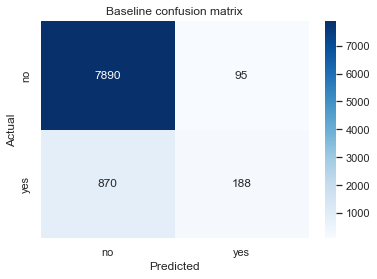

In [12]:
# Dummy reference: always predict "no"
dummy_acc = 1 - y_test.mean()
print("Accuracy of always saying 'no': %.3f (recall = 0)" % dummy_acc)

base = Pipeline([("prep", make_preprocessor(X_train)),
                 ("model", LogisticRegression(max_iter=1000, random_state=SEED))])
base, pred_base, proba_base = evaluate("Logistic Regression (baseline)", base, X_train, X_test)

print(classification_report(y_test, pred_base, target_names=["no", "yes"]))
plot_cm(y_test, pred_base, "Baseline confusion matrix")

The baseline has high accuracy but low recall for `yes`: with a default threshold of 0.5 it misses most subscribers. A common fix is `class_weight="balanced"`, which gives more weight to the rare class. We try that next.

In [13]:
bal = Pipeline([("prep", make_preprocessor(X_train)),
                ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))])
bal, pred_bal, proba_bal = evaluate("Logistic Regression (balanced)", bal, X_train, X_test)
pd.DataFrame(results).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression (baseline),0.893,0.664,0.178,0.280,0.772
1,Logistic Regression (balanced),0.755,0.267,0.624,0.374,0.772


# 4. Compare different models
We add three more scikit-learn classifiers: a Decision Tree, a Random Forest and Gradient Boosting. Trees are shallow or limited so they do not overfit. Same data, same split, same features.

In [14]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=5, max_depth=12,
                                            class_weight="balanced", n_jobs=-1, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}
fitted = {}
for name, m in models.items():
    pipe = Pipeline([("prep", make_preprocessor(X_train)), ("model", m)])
    fitted[name] = evaluate(name, pipe, X_train, X_test)

comp = pd.DataFrame(results).set_index("Model").round(3)
comp

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression (baseline),0.893,0.664,0.178,0.280,0.772
Logistic Regression (balanced),0.755,0.267,0.624,0.374,0.772
Decision Tree,0.796,0.301,0.560,0.391,0.739
Random Forest,0.828,0.361,0.604,0.452,0.799
Gradient Boosting,0.894,0.659,0.199,0.306,0.802


Note: Gradient Boosting has no `class_weight`, so it uses the default 0.5 threshold and is conservative (like the first baseline). Because the models use different thresholds, **ROC AUC** (threshold independent) is the fairest single comparison; precision/recall depend on the threshold.

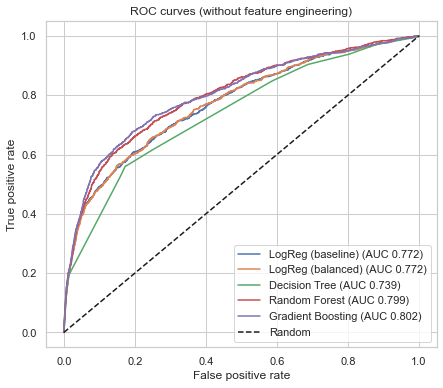

In [15]:
# ROC curves of all models
plt.figure(figsize=(7, 6))
probas = {"LogReg (baseline)": proba_base, "LogReg (balanced)": proba_bal}
probas.update({k: v[2] for k, v in fitted.items()})
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label="%s (AUC %.3f)" % (name, roc_auc_score(y_test, p)))
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves (without feature engineering)"); plt.legend(); plt.show()

# 5. Feature engineering
New features and the reasoning:
1. **`contacted_before`** (1 if `pdays != -1`): `pdays = -1` is a code, not a number; treating it as 'days' confuses linear models. A simple yes/no says whether the customer is a known contact.
2. **`has_any_loan`** (housing or personal loan): customers with debt have less free money for a deposit; one combined flag is easier to learn than two weak ones.
3. **`balance_positive`** and **`log_balance`**: balance is very skewed with negatives; a log-type transform reduces the effect of extreme values.
4. **`age_group`**: age and subscription are not linear (the young and the old subscribe more), so bands help linear models.
5. **`season`** (quarter from `month`): months are noisy; grouping into quarters gives a more stable seasonal signal.
6. **`campaign_high`** (more than 3 calls in this campaign): many calls to one person usually signal low interest.

Features are created from each row's own values only (no information from other rows), so there is no leakage and it is safe to apply to the full table before the split; we then reuse the same split indices.

In [16]:
def add_features(d):
    d = d.copy()
    d["contacted_before"] = (d["pdays"] != -1).astype(int)
    d["has_any_loan"] = ((d["housing"] == "yes") | (d["loan"] == "yes")).astype(int)
    d["balance_positive"] = (d["balance"] > 0).astype(int)
    d["log_balance"] = np.sign(d["balance"]) * np.log1p(d["balance"].abs())
    d["age_group"] = pd.cut(d["age"], [0, 25, 35, 45, 55, 65, 120],
                            labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]).astype(str)
    quarter = {"jan": "Q1", "feb": "Q1", "mar": "Q1", "apr": "Q2", "may": "Q2", "jun": "Q2",
               "jul": "Q3", "aug": "Q3", "sep": "Q3", "oct": "Q4", "nov": "Q4", "dec": "Q4"}
    d["season"] = d["month"].map(quarter)
    d["campaign_high"] = (d["campaign"] > 3).astype(int)
    return d

X_fe = add_features(X)
X_train_fe, X_test_fe = X_fe.loc[X_train.index], X_fe.loc[X_test.index]

# quick check: do the new features relate to the target?
chk = add_features(df)
print(chk.groupby("contacted_before")["target"].mean().round(3), "\n")
print(chk.groupby("has_any_loan")["target"].mean().round(3), "\n")
print(chk.groupby("age_group")["target"].mean().round(3), "\n")
print(chk.groupby("campaign_high")["target"].mean().round(3))

contacted_before
0    0.092
1    0.231
Name: target, dtype: float64 

has_any_loan
0    0.182
1    0.077
Name: target, dtype: float64 

age_group
26-35    0.120
36-45    0.094
46-55    0.094
56-65    0.141
65+      0.426
<=25     0.240
Name: target, dtype: float64 

campaign_high
0    0.129
1    0.074
Name: target, dtype: float64


In [17]:
# Same models again, now with the extra features
results_fe = []
def run_fe(name, model):
    pipe = Pipeline([("prep", make_preprocessor(X_train_fe)), ("model", model)])
    out = evaluate(name + " + FE", pipe, X_train_fe, X_test_fe, store=False)
    return out

fe_models = {
    "Logistic Regression (baseline)": LogisticRegression(max_iter=1000, random_state=SEED),
    "Logistic Regression (balanced)": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "Gradient Boosting": models["Gradient Boosting"],
}
fe_fitted = {}
rows = []
for name, m in fe_models.items():
    model, pred, proba = run_fe(name, m)
    fe_fitted[name] = (model, pred, proba)
    rows.append({"Model": name + " + FE",
                 "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred),
                 "ROC AUC": roc_auc_score(y_test, proba)})

all_res = pd.concat([pd.DataFrame(results), pd.DataFrame(rows)]).set_index("Model").round(3)
all_res

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression (baseline),0.893,0.664,0.178,0.280,0.772
Logistic Regression (balanced),0.755,0.267,0.624,0.374,0.772
Decision Tree,0.796,0.301,0.560,0.391,0.739
Random Forest,0.828,0.361,0.604,0.452,0.799
Gradient Boosting,0.894,0.659,0.199,0.306,0.802
Logistic Regression (baseline) + FE,0.893,0.640,0.186,0.288,0.775
Logistic Regression (balanced) + FE,0.764,0.279,0.642,0.389,0.775
Decision Tree + FE,0.810,0.313,0.522,0.391,0.738
Random Forest + FE,0.834,0.368,0.590,0.453,0.799


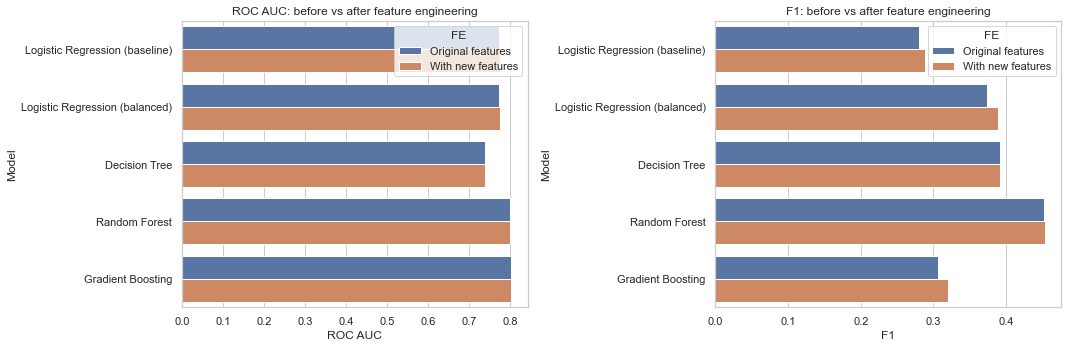

In [18]:
# Before vs after feature engineering (ROC AUC and F1)
plot_df = all_res.reset_index()
plot_df["FE"] = np.where(plot_df["Model"].str.endswith("+ FE"), "With new features", "Original features")
plot_df["Model"] = plot_df["Model"].str.replace(" + FE", "", regex=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ["ROC AUC", "F1"]):
    sns.barplot(data=plot_df, y="Model", x=metric, hue="FE", ax=ax)
    ax.set_title(metric + ": before vs after feature engineering")
plt.tight_layout(); plt.show()

## Side experiment: why we dropped `duration`
Same Gradient Boosting, but with `duration` included. This is **not** a valid model for choosing whom to call (leakage); it only shows how much the leaked variable inflates the score.

In [19]:
X_leak = add_features(df.drop(columns=["y", "target"]))
leak = Pipeline([("prep", make_preprocessor(X_leak)),
                 ("model", GradientBoostingClassifier(random_state=SEED))])
leak.fit(X_leak.loc[X_train.index], y_train)
p_leak = leak.predict_proba(X_leak.loc[X_test.index])[:, 1]
print("ROC AUC with duration (leakage): %.3f" % roc_auc_score(y_test, p_leak))
print("ROC AUC without duration:        %.3f" % all_res.loc["Gradient Boosting + FE", "ROC AUC"])

ROC AUC with duration (leakage): 0.925
ROC AUC without duration:        0.802


# 6. Interpret the results

In [20]:
# Best model by ROC AUC (the threshold-independent metric)
best_name = all_res["ROC AUC"].idxmax()
print("Best by ROC AUC:", best_name)
all_res.sort_values("ROC AUC", ascending=False)

Best by ROC AUC: Gradient Boosting


,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Gradient Boosting,0.894,0.659,0.199,0.306,0.802
Gradient Boosting + FE,0.895,0.666,0.211,0.320,0.802
Random Forest,0.828,0.361,0.604,0.452,0.799
Random Forest + FE,0.834,0.368,0.590,0.453,0.799
Logistic Regression (baseline) + FE,0.893,0.640,0.186,0.288,0.775
Logistic Regression (balanced) + FE,0.764,0.279,0.642,0.389,0.775
Logistic Regression (baseline),0.893,0.664,0.178,0.280,0.772
Logistic Regression (balanced),0.755,0.267,0.624,0.374,0.772
Decision Tree,0.796,0.301,0.560,0.391,0.739


poutcome_success    0.385
age                 0.060
pdays               0.059
has_any_loan        0.056
day                 0.050
month_mar           0.046
contact_unknown     0.045
month_apr           0.042
dtype: float64


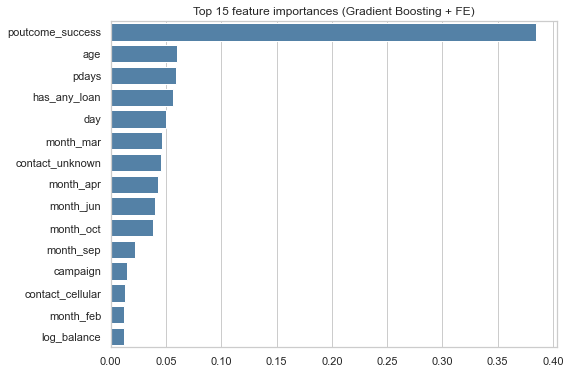

In [21]:
# Which features matter? Use the best tree-based model (Gradient Boosting + FE)
gb_pipe = fe_fitted["Gradient Boosting"][0]
prep = gb_pipe.named_steps["prep"]
num_names = prep.transformers_[0][2]
cat_names = list(prep.named_transformers_["cat"].get_feature_names(prep.transformers_[1][2]))
names = list(num_names) + cat_names
imp = pd.Series(gb_pipe.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)
print(imp.round(3).head(8))
plt.figure(figsize=(8, 6))
sns.barplot(x=imp.values, y=[n.replace("num__", "").replace("cat__", "") for n in imp.index], color="steelblue")
plt.title("Top 15 feature importances (Gradient Boosting + FE)")
plt.show()

In [22]:
# Business view: if we only call the top-scored customers, how many yes do we reach?
best_proba = fe_fitted["Gradient Boosting"][2]
scored = pd.DataFrame({"y": y_test.values, "p": best_proba}).sort_values("p", ascending=False).reset_index(drop=True)
total_yes = scored["y"].sum()
rows = []
for share in [0.1, 0.2, 0.3, 0.5, 1.0]:
    n = int(len(scored) * share)
    got = scored["y"].iloc[:n].sum()
    rows.append({"Customers called (%)": int(share * 100),
                 "Subscribers reached (%)": round(100 * got / total_yes, 1),
                 "Success rate among called (%)": round(100 * got / n, 1),
                 "Lift vs random": round((got / n) / y_test.mean(), 2)})
gains = pd.DataFrame(rows)
gains

,Customers called (%),Subscribers reached (%),Success rate among called (%),Lift vs random
0,10,44.1,51.7,4.42
1,20,62.0,36.3,3.10
2,30,70.5,27.5,2.35
3,50,83.0,19.4,1.66
4,100,100.0,11.7,1.00


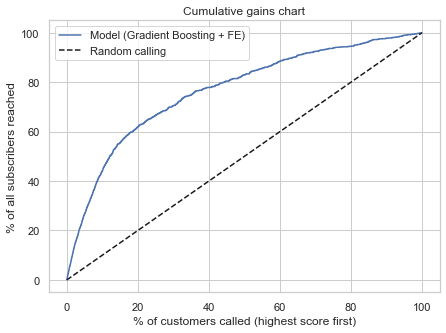

In [23]:
plt.figure(figsize=(7, 5))
x = np.arange(1, len(scored) + 1) / len(scored) * 100
plt.plot(x, scored["y"].cumsum() / total_yes * 100, label="Model (Gradient Boosting + FE)")
plt.plot([0, 100], [0, 100], "k--", label="Random calling")
plt.xlabel("% of customers called (highest score first)")
plt.ylabel("% of all subscribers reached")
plt.title("Cumulative gains chart"); plt.legend(); plt.show()

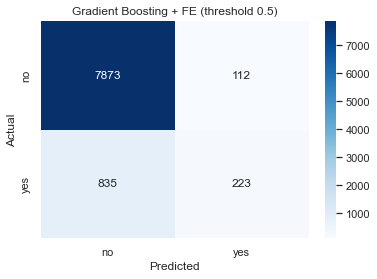

In [24]:
# Confusion matrix of the best model
plot_cm(y_test, fe_fitted["Gradient Boosting"][1], "Gradient Boosting + FE (threshold 0.5)")

## Final conclusions (business view)

**What drives subscriptions**
- Only 11.7% of customers subscribed, so the data is imbalanced and accuracy alone is misleading (always saying "no" gives 88.3%).
- The strongest signal is the **previous campaign outcome**: customers with a previous success subscribed 64.7% of the time versus 9.2% for customers with no previous contact. It is also by far the most important feature in Gradient Boosting (importance 0.385, the next one is 0.060).
- Other helpful signals: **age** (under 25: 24.0%, over 65: 42.6%, versus about 9-12% for ages 26-55), **job** (students 28.7%, retired 22.8%, blue-collar 7.3%), **no housing or personal loan** (18.2% versus 7.7% for the new `has_any_loan` flag), **known contact type** (`unknown` contact: 4.1% versus 14.9% cellular), and **fewer calls** (more than 3 calls: 7.4% versus 12.9%).
- Timing matters (March, September, October, December convert best), but these months have few contacts, so we should test this before changing the calendar.

**Model comparison (test set, 9,043 customers, `duration` excluded)**

| Model | Precision | Recall | F1 | ROC AUC |
|---|---|---|---|---|
| Logistic Regression (baseline) | 0.664 | 0.178 | 0.280 | 0.772 |
| Logistic Regression (balanced) | 0.267 | 0.624 | 0.374 | 0.772 |
| Decision Tree | 0.301 | 0.560 | 0.391 | 0.739 |
| Random Forest | 0.361 | 0.604 | 0.452 | 0.799 |
| Gradient Boosting | 0.659 | 0.199 | 0.306 | 0.802 |
| Gradient Boosting + new features | 0.666 | 0.211 | 0.320 | 0.802 |

- **Gradient Boosting and Random Forest rank customers best** (ROC AUC about 0.80, versus 0.77 for the Logistic Regression baseline and 0.74 for the Decision Tree).
- The baseline Logistic Regression and Gradient Boosting have high precision but find only 18-21% of subscribers at the default 0.5 threshold. The "balanced" models and the Random Forest find about 56-64% of subscribers, but with more false alarms. **Random Forest has the best F1 (0.45)**. The choice between these depends on the cost of a call versus the value of a subscription.
- **Feature engineering helped only a little** (ROC AUC +0.003 for Logistic Regression, F1 +0.014 for Gradient Boosting, no change for Random Forest). The tree models can already find these patterns from the raw variables.
- **Leakage check:** with `duration` included, ROC AUC jumps from 0.802 to 0.925, but that variable is only known after the call, so it cannot be used to plan a campaign.

**How the bank can use this**
- Score every customer before the campaign and call them in order of score. With Gradient Boosting, calling the **top 10%** reaches 44.1% of all subscribers (51.7% success rate, 4.4 times better than random); the **top 20%** reaches 62.0% (3.1 times better); the top 50% reaches 83.0%. This saves many calls.
- Prioritise customers with a previous successful campaign, students, retired and older customers, and customers without loans; avoid repeated calls (more than 3) to the same person.
- Use the Random Forest or balanced models when the goal is to find as many subscribers as possible, and Gradient Boosting when the budget is tight and precision matters.

**Limitations**
- Data comes from one bank and one past period; results may change for new campaigns, so a small pilot test is recommended.
- Results are from a single train/test split with default or lightly set hyperparameters; no tuning or cross-validation was done, so small differences (for example between the two ROC AUC values 0.802 and 0.799) are not conclusive.
- Patterns are correlations, not proof that a characteristic *causes* subscription.
- Next steps: cross-validation, hyperparameter tuning, choosing the decision threshold from real call costs and deposit value.